<a href="https://colab.research.google.com/github/Zehrayt/izge/blob/main/izge_cnn_model_pipeline.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
from google.colab import drive
import os

# 1. Google Drive'ı Colab oturumuna bağlıyoruz
drive.mount('/content/drive')

# 2. Dinamik Yol Kontrolü gerçekleştiriyoruz
drive_path = '/content/drive/MyDrive/izge_kelime_veri.zip'

print("\n=== SİSTEM BAĞLANTI KONTROLÜ ===")
if os.path.exists(drive_path):
    print("✓ Harika! 'izge_kelime_veri.zip' paketi Drive ana dizininde başarıyla bulundu.")
    print("👉 Bir sonraki hücreye (Hücre 2) geçerek zip paketini patlatabilirsin.")
else:
    print("✗ HATA: Klasör veya Zip paketi bulunamadı!")
    print("Lütfen bilgisayarındaki zip dosyasını Drive'ının ana sayfasına (My Drive) doğru isimle yüklediğinden emin ol.")
print("================================")

Mounted at /content/drive

=== SİSTEM BAĞLANTI KONTROLÜ ===
✓ Harika! 'izge_kelime_veri.zip' paketi Drive ana dizininde başarıyla bulundu.
👉 Bir sonraki hücreye (Hücre 2) geçerek zip paketini patlatabilirsin.


In [3]:
# Sürücüdeki zip dosyasını Colab'in yerel diskine sessizce çıkarıyoruz
!unzip -q /content/drive/MyDrive/izge_kelime_veri.zip -d /content/

In [4]:
import os

# Zip dosyasından çıkardığımız yerel veri yolu
veri_yolu = '/content/izge_kelime_veri'

print("🔍 Veri seti alt klasörleri ve dosya sayıları denetleniyor...\n")

if os.path.exists(veri_yolu):
    print("=========================================")
    print("📊 İZGE HAM VERİ HAVUZU KONTROL RAPORU")
    print("=========================================")

    # Sadece alt klasörleri (kelimeleri) alfabetik sırayla topluyoruz
    klasorler = sorted([d for d in os.listdir(veri_yolu) if os.path.isdir(os.path.join(veri_yolu, d))])

    toplam_gorsel_sayisi = 0

    for kelime in klasorler:
        klasor_yolu = os.path.join(veri_yolu, kelime)

        # Klasörün içindeki hem .png hem de .jpg/.jpeg uzantılı tüm dosyaları yakalayıp sayıyoruz
        dosyalar = [f for f in os.listdir(klasor_yolu) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
        gorsel_sayisi = len(dosyalar)
        toplam_gorsel_sayisi += gorsel_sayisi

        # Tam istediğin formatta ekrana yazdırıyoruz:
        print(f"📂 {kelime}: {gorsel_sayisi} adet gerçek el yazısı görseli var.")

    print("=========================================")
    print(f"✨ GENEL TOPLAM: {toplam_gorsel_sayisi} adet el yazısı verisi kullanıma hazır!")
    print("=========================================")
else:
    print("✗ HATA: '/content/izge_kelime_veri' klasörü bulunamadı!")
    print("Lütfen bir yukarıdaki Hücre 2'de zip dosyasını başarıyla patlattığından emin ol.")

🔍 Veri seti alt klasörleri ve dosya sayıları denetleniyor...

📊 İZGE HAM VERİ HAVUZU KONTROL RAPORU
📂 baba: 200 adet gerçek el yazısı görseli var.
📂 dede: 200 adet gerçek el yazısı görseli var.
📂 gemi: 250 adet gerçek el yazısı görseli var.
📂 kalem: 200 adet gerçek el yazısı görseli var.
📂 para: 200 adet gerçek el yazısı görseli var.
✨ GENEL TOPLAM: 1050 adet el yazısı verisi kullanıma hazır!


In [5]:
import os
import cv2
import numpy as np
from PIL import Image

# Bir önceki hücrenin belirlediği dinamik ve akıllı yolu miras alıyoruz
# Eğer üstteki hücre sıfırlandıysa manuel güvenli yol ataması yapıyoruz
veri_yolu = '/content/izge_kelime_veri'
if not os.path.exists(veri_yolu):
    veri_yolu = '/content'
if len([d for d in os.listdir(veri_yolu) if os.path.isdir(os.path.join(veri_yolu, d)) and not d.startswith('.')]) <= 1:
    for sub in os.listdir(veri_yolu):
        if os.path.isdir(os.path.join(veri_yolu, sub)) and not sub.startswith('.') and sub != 'sample_data':
            veri_yolu = os.path.join(veri_yolu, sub)

print("🔄 1. Arayüz format mühürlemesi başlatıldı...")
for kok_dizin, _, dosyalar in os.walk(veri_yolu):
    for dosya in dosyalar:
        if dosya.lower().endswith(('.jpg', '.jpeg')):
            jpg_yolu = os.path.join(kok_dizin, dosya)
            img = Image.open(jpg_yolu)
            png_yolu = os.path.splitext(jpg_yolu)[0] + '.png'
            img.save(png_yolu, 'PNG', optimize=True)
            os.remove(jpg_yolu)

print("✓ Tüm uzantılar senkronize edildi.")
print("\n🔄 2. Görseller yapay zeka matrisine dönüştürülüyor...")

klasorler = sorted([d for d in os.listdir(veri_yolu) if os.path.isdir(os.path.join(veri_yolu, d)) and not d.startswith('.')])
ETIKET_MAP = {k: i for i, k in enumerate(klasorler)}

X_canvas = []
y_etiketler = []

for kelime in klasorler:
    klasor_yolu = os.path.join(veri_yolu, kelime)
    dosyalar = [f for f in os.listdir(klasor_yolu) if f.lower().endswith('.png')]
    for dosya in dosyalar:
        img_yolu = os.path.join(klasor_yolu, dosya)
        img = cv2.imread(img_yolu, cv2.IMREAD_GRAYSCALE)
        img = cv2.resize(img, (128, 32))
        X_canvas.append(img)
        y_etiketler.append(ETIKET_MAP[kelime])

X_canvas = np.array(X_canvas).reshape(-1, 1, 32, 128).astype('float32') / 255.0
y_etiketler = np.array(y_etiketler)
print(f"✓ Matris Hazır! Toplam Veri: {X_canvas.shape[0]} | Boyut: {X_canvas.shape[2]}x{X_canvas.shape[3]}")

🔄 1. Arayüz format mühürlemesi başlatıldı...
✓ Tüm uzantılar senkronize edildi.

🔄 2. Görseller yapay zeka matrisine dönüştürülüyor...
✓ Matris Hazır! Toplam Veri: 1050 | Boyut: 32x128


In [6]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split

# GPU (Ekran Kartı) kontrolü - Colab hızı için kritik!
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"🖥️ Model şu an donanım olarak burada eğitiliyor: {device}\n")

# %15 dürüst test ayrımı
X_train, X_test, y_train, y_test = train_test_split(
    X_canvas, y_etiketler, test_size=0.15, random_state=42, shuffle=True, stratify=y_etiketler
)

X_train_t = torch.tensor(X_train, dtype=torch.float32)
y_train_t = torch.tensor(y_train, dtype=torch.long)
X_test_t = torch.tensor(X_test, dtype=torch.float32)
y_test_t = torch.tensor(y_test, dtype=torch.long)

train_loader = DataLoader(TensorDataset(X_train_t, y_train_t), batch_size=32, shuffle=True)
test_loader = DataLoader(TensorDataset(X_test_t, y_test_t), batch_size=32, shuffle=False)

# Hafif CNN Mimarisi
class IzgeHafifCNN(nn.Module):
    def __init__(self, sinif_sayisi=5):
        super(IzgeHafifCNN, self).__init__()
        self.conv1 = nn.Conv2d(1, 16, kernel_size=3, padding=1)
        self.relu1 = nn.ReLU()
        self.pool1 = nn.MaxPool2d(2, 2)

        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, padding=1)
        self.relu2 = nn.ReLU()
        self.pool2 = nn.MaxPool2d(2, 2)

        self.fc1 = nn.Linear(32 * 8 * 32, 128)
        self.relu3 = nn.ReLU()
        self.dropout = nn.Dropout(0.5) # Overfitting Düşmanı!
        self.fc2 = nn.Linear(128, sinif_sayisi)

    def forward(self, x):
        x = self.pool1(self.relu1(self.conv1(x)))
        x = self.pool2(self.relu2(self.conv2(x)))
        x = x.view(x.size(0), -1)
        x = self.relu3(self.fc1(x))
        x = self.dropout(x)
        return self.fc2(x)

model = IzgeHafifCNN(sinif_sayisi=5).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

train_losses, train_accuracies = [], []
EPOCHS = 20

for epoch in range(EPOCHS):
    model.train()
    toplam_loss, dogru = 0, 0
    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        optimizer.zero_grad()
        outputs = model(X_batch)
        loss = criterion(outputs, y_batch)
        loss.backward()
        optimizer.step()

        toplam_loss += loss.item()
        _, preds = torch.max(outputs, 1)
        dogru += (preds == y_batch).sum().item()

    epoch_loss = toplam_loss / len(train_loader)
    epoch_acc = (dogru / len(X_train)) * 100
    train_losses.append(epoch_loss)
    train_accuracies.append(epoch_acc)
    print(f"Epoch {epoch+1:02d}/{EPOCHS} -> Loss: {epoch_loss:.4f} | Doğruluk: %{epoch_acc:.2f}")

# Modeli mühürleme
torch.save(model.state_dict(), '/content/drive/MyDrive/izge_kelime_model.pth')
print("\n✓ Model başarıyla eğitildi ve Drive hesabınıza mühürlendi!")

🖥️ Model şu an donanım olarak burada eğitiliyor: cpu

Epoch 01/20 -> Loss: 1.6071 | Doğruluk: %25.00
Epoch 02/20 -> Loss: 1.3081 | Doğruluk: %45.07
Epoch 03/20 -> Loss: 1.0231 | Doğruluk: %56.95
Epoch 04/20 -> Loss: 0.8616 | Doğruluk: %65.58
Epoch 05/20 -> Loss: 0.7468 | Doğruluk: %71.19
Epoch 06/20 -> Loss: 0.6821 | Doğruluk: %73.77
Epoch 07/20 -> Loss: 0.6234 | Doğruluk: %76.91
Epoch 08/20 -> Loss: 0.5397 | Doğruluk: %80.16
Epoch 09/20 -> Loss: 0.4884 | Doğruluk: %82.29
Epoch 10/20 -> Loss: 0.4295 | Doğruluk: %85.09
Epoch 11/20 -> Loss: 0.4125 | Doğruluk: %85.65
Epoch 12/20 -> Loss: 0.3363 | Doğruluk: %88.68
Epoch 13/20 -> Loss: 0.3364 | Doğruluk: %88.45
Epoch 14/20 -> Loss: 0.2544 | Doğruluk: %91.48
Epoch 15/20 -> Loss: 0.2389 | Doğruluk: %93.05
Epoch 16/20 -> Loss: 0.2101 | Doğruluk: %93.05
Epoch 17/20 -> Loss: 0.1813 | Doğruluk: %94.84
Epoch 18/20 -> Loss: 0.1736 | Doğruluk: %94.28
Epoch 19/20 -> Loss: 0.1491 | Doğruluk: %95.07
Epoch 20/20 -> Loss: 0.1469 | Doğruluk: %95.07

✓ Mod

🎨 Başarı Grafikleri ve Isı Haritası Hazırlanıyor...



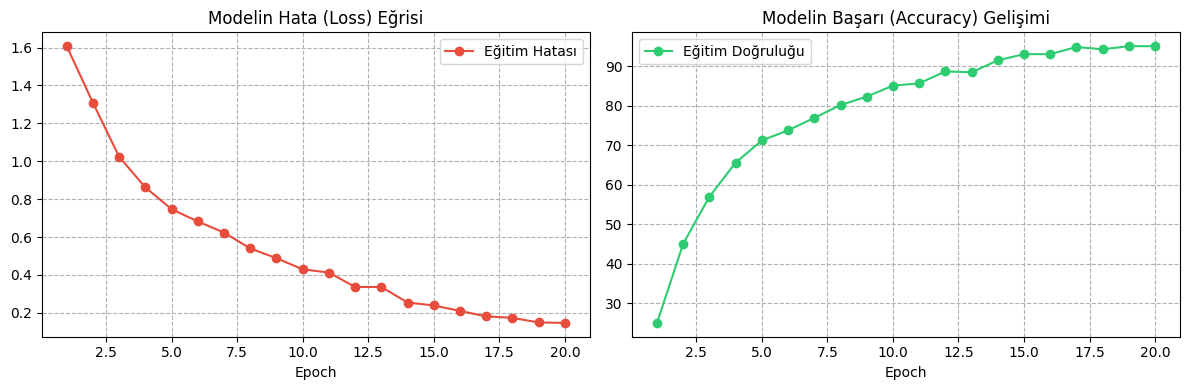

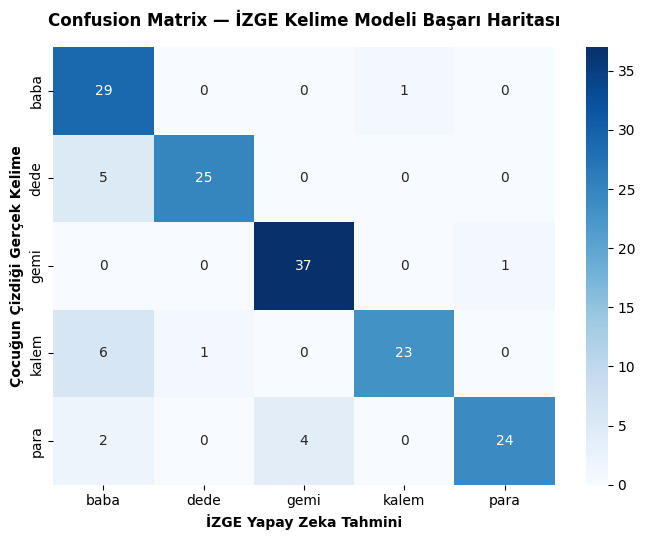


====================== MODEL TEST SONUÇLARI ======================
              precision    recall  f1-score   support

        baba       0.69      0.97      0.81        30
        dede       0.96      0.83      0.89        30
        gemi       0.90      0.97      0.94        38
       kalem       0.96      0.77      0.85        30
        para       0.96      0.80      0.87        30

    accuracy                           0.87       158
   macro avg       0.89      0.87      0.87       158
weighted avg       0.89      0.87      0.88       158



In [8]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

print("🎨 Başarı Grafikleri ve Isı Haritası Hazırlanıyor...\n")

# 1. Eğitim Gelişim Eğrileri
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(range(1, len(train_losses) + 1), train_losses, marker='o', color='#e74c3c', label='Eğitim Hatası')
plt.title('Modelin Hata (Loss) Eğrisi')
plt.xlabel('Epoch')
plt.grid(True, linestyle='--')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(range(1, len(train_accuracies) + 1), train_accuracies, marker='o', color='#2ecc71', label='Eğitim Doğruluğu')
plt.title('Modelin Başarı (Accuracy) Gelişimi')
plt.xlabel('Epoch')
plt.grid(True, linestyle='--')
plt.legend()
plt.tight_layout()
plt.show()

# 2. Confusion Matrix Testi
model.eval()
tum_tahminler, tum_gercekler = [], []

with torch.no_grad():
    for X_batch, y_batch in test_loader:
        X_batch = X_batch.to(device)
        outputs = model(X_batch)
        _, preds = torch.max(outputs, 1)
        tum_tahminler.extend(preds.cpu().numpy())
        tum_gercekler.extend(y_batch.numpy())

cm = confusion_matrix(tum_gercekler, tum_tahminler)
plt.figure(figsize=(7, 5.5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=klasorler, yticklabels=klasorler)
plt.xlabel('İZGE Yapay Zeka Tahmini', fontweight='bold')
plt.ylabel('Çocuğun Çizdiği Gerçek Kelime', fontweight='bold')
plt.title('Confusion Matrix — İZGE Kelime Modeli Başarı Haritası', fontweight='bold', pad=15)
plt.tight_layout()
plt.show()
# 3. METRİK GRUBU: Yapay Zeka Test Sonuçları Çıktısı
print("\n" + "="*22 + " MODEL TEST SONUÇLARI " + "="*22)
print(classification_report(tum_gercekler, tum_tahminler, target_names=klasorler))
print("="*67)